In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
import torch
from torchvision import transforms, datasets
from google.colab import drive
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
import torch.nn as nn

In [3]:
data_dir = '/content/drive/MyDrive/soyaleaf_detection'

In [ ]:
transform = transforms.Compose([
    # Resize the image to a consistent size (e.g., 224x224)
    transforms.Resize((224, 224)),

    # Randomly flip the image horizontally (with a 50% probability)
    transforms.RandomHorizontalFlip(p=0.5),


    # Convert the image to a PyTorch tensor
    
    transforms.ToTensor(),

    # Normalize the image based on typical RGB mean and standard deviation
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
dataset = datasets.ImageFolder(data_dir, transform=transform)

In [6]:
dataset

Dataset ImageFolder
    Number of datapoints: 1145
    Root location: /content/drive/MyDrive/soyaleaf_detection
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [7]:
classes = dataset.classes

In [8]:
classes

['Yellow_Mosaic_Disease', 'normal']

In [9]:
train_size = int(0.8*len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [10]:
print(len(dataset))
print(len(train_dataset))
print(len(test_dataset))

1145
916
229


In [11]:
batch_size = 7
data_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

num_samples = len(dataset)

print(num_samples)


1145


In [12]:
for images, labels in data_loader:
    fig, axs = plt.subplots(1, 3, figsize=(12, 3))
    for i in range(3):
        # Convert the image tensor to a NumPy array and transpose it to (H, W, C) format
        image = images[i].numpy().transpose((1, 2, 0))
        axs[i].imshow(image)
        axs[i].set_title(classes[labels[i]])
        axs[i].axis('off')
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

In [13]:
#model defination
class BaselineModel(nn.Module):
    def __init__(self, num_classes):
        super(BaselineModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)#3color channels(red, green, and blue),Number of Output Channels (16),Kernel Size (3x3)Common choices are 3x3 or 5x5
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(16 * 112 * 112, num_classes)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(-1, 16 * 112 * 112)
        x = self.fc(x)
        return x

num_classes = 2
baseline_model = BaselineModel(num_classes)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(baseline_model.parameters(), lr=0.001)


In [14]:
#the training loop
import torch

# Assuming you have already defined your model, criterion, and optimizer
# model = BaselineModel(num_classes)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

# Set the number of training epochs

train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

num_epochs = 10

for epoch in range(num_epochs):
    baseline_model.train()  # Set the model to training mode

    running_loss = 0.0  # Initialize the running loss

    for images, labels in train_loader:  # Iterate over the training dataset
        optimizer.zero_grad()  # Zero the gradients

        # Forward pass
        outputs = baseline_model(images)

        # Calculate the loss
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate the average training loss for the epoch
    average_loss = running_loss / len(train_loader)

    print(f'Epoch [{epoch + 1}/{num_epochs}] - Loss: {average_loss:.4f}')

print('Training complete')

Epoch [1/10] - Loss: 0.2342
Epoch [2/10] - Loss: 0.0555
Epoch [3/10] - Loss: 0.0420
Epoch [4/10] - Loss: 0.0314
Epoch [5/10] - Loss: 0.0124
Epoch [6/10] - Loss: 0.0088
Epoch [7/10] - Loss: 0.0057
Epoch [8/10] - Loss: 0.0042
Epoch [9/10] - Loss: 0.0062
Epoch [10/10] - Loss: 0.0034
Training complete


In [15]:
#define a data loader for the test dataset
test_loader = DataLoader(test_dataset,batch_size=batch_size,shuffle=False)

In [16]:
#create functions to evaluate the modelto calculate accuracy
def calculate_accuracy(model, data_loader):
  model.eval() #sets the model to evaluation mode
  correct = 0
  total = 0


  with torch.no_grad():
    for images, labels in data_loader:
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total +=labels.size(0)
      correct +=(predicted == labels).sum().item()


  return(correct /total) *100

In [17]:
test_accuracy = calculate_accuracy(baseline_model, test_loader)
print(f'Test Accuracy:{test_accuracy:2f}% ')

Test Accuracy:100.000000% 


In [18]:
#saving the trained model for reuse in prediction or further training
torch.save(baseline_model.state_dict(), '/content/drive/MyDrive/soyaleaf_detection/baseline_model.pth')

In [20]:
loaded_model = BaselineModel(num_classes)

#load the model weights
loaded_model.load_state_dict(torch.load('/content/drive/MyDrive/soyaleaf_detection/baseline_model.pth'))

<All keys matched successfully>

In [21]:
loaded_model.eval()

BaselineModel(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=200704, out_features=2, bias=True)
)

In [22]:
from PIL import Image
image_path = '/content/angular_leaf_spot_train.2.jpg'
new_image = Image.open(image_path)

In [23]:
image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.29,0.224, 0.225])

])

In [30]:
input_image =Image.open('/content/angular_leaf_spot_train.2.jpg')
input_image = image_transform(input_image)

In [25]:
loaded_model.eval()

#pass the preprocessednimage through the model

with torch.no_grad():
  output = loaded_model(input_image.unsqueeze(0)) #unsqueezing to add a batch dimension

In [27]:
class_labels = ["yellow mosaic disease", "Normal Leaf"]

#Get the predicted class index
_, predicted_class = output.max(1)

#Get the predicted class label
predicted_label = class_labels[predicted_class]

#print the predicted class label

print(f"predicted Class: {predicted_label}")


predicted Class: Normal Leaf


In [28]:
predicted_prob = torch.softmax(output, dim=1)[0][predicted_class].item()

print(f"Confidence: {predicted_prob *100:2f}%")

Confidence: 89.102632%


In [32]:
!pip install matplotlib scikit-learn seaborn --quiet

In [33]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)


In [34]:
def evaluate_metrics(model, data_loader, num_classes):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    # Simple IoU for classification (per-class)
    iou_per_class = []
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    for i in range(num_classes):
        tp = cm[i,i]
        fn = cm[i,:].sum() - tp
        fp = cm[:,i].sum() - tp
        denom = tp + fp + fn
        iou = tp/denom if denom>0 else 0.0
        iou_per_class.append(iou)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "iou_per_class": iou_per_class,
        "confusion_matrix": cm
    }


In [35]:
def evaluate_metrics(model, data_loader, num_classes):
    model.eval()
    all_labels, all_preds = [], []
    with torch.no_grad():
        for images, labels in data_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds  = np.array(all_preds)

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    rec  = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1   = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    # Simple IoU for classification (per-class)
    iou_per_class = []
    cm = confusion_matrix(all_labels, all_preds, labels=list(range(num_classes)))
    for i in range(num_classes):
        tp = cm[i,i]
        fn = cm[i,:].sum() - tp
        fp = cm[:,i].sum() - tp
        denom = tp + fp + fn
        iou = tp/denom if denom>0 else 0.0
        iou_per_class.append(iou)

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "iou_per_class": iou_per_class,
        "confusion_matrix": cm
    }


In [36]:
def plot_metrics(metrics, class_names):
    # 1. Confusion Matrix Heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(metrics["confusion_matrix"], annot=True, fmt="d",
                xticklabels=class_names, yticklabels=class_names, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # 2. Bar chart for per-class IoU
    plt.figure(figsize=(6,4))
    plt.bar(class_names, metrics["iou_per_class"], color="teal")
    plt.ylim(0,1)
    plt.ylabel("IoU")
    plt.title("IoU per Class")
    plt.show()


Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
IoU per class: {'yellow mosaic disease': np.float64(1.0), 'Normal': np.float64(1.0)}


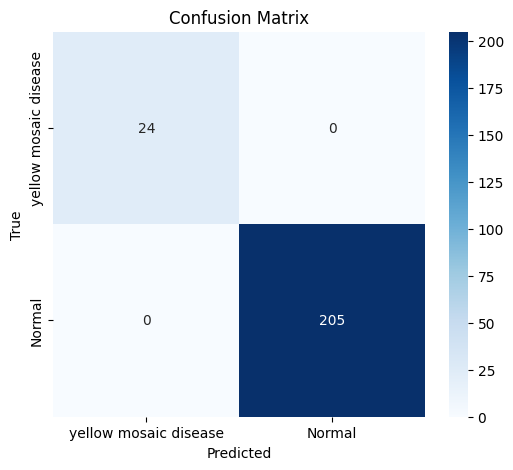

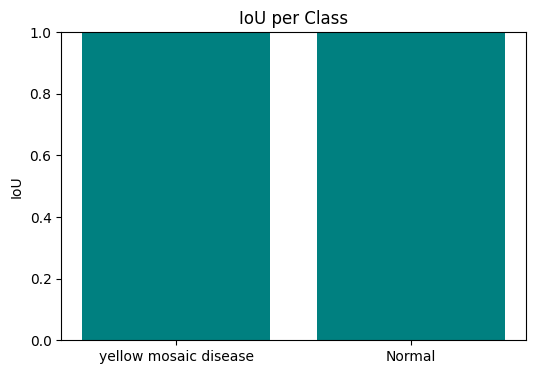

In [38]:
class_labels = ["yellow mosaic disease", "Normal"]
metrics = evaluate_metrics(loaded_model, test_loader, num_classes=len(class_labels))
print("Accuracy :", metrics["accuracy"])
print("Precision:", metrics["precision"])
print("Recall   :", metrics["recall"])
print("F1 Score :", metrics["f1"])
print("IoU per class:", dict(zip(class_labels, metrics["iou_per_class"])))

plot_metrics(metrics, class_labels)


In [39]:
from PIL import Image
import torchvision.transforms as transforms

def predict_and_show(image_path, model, class_labels):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])  # fixed std typo
    ])
    image = Image.open(image_path).convert("RGB")
    tensor = transform(image).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        conf, pred_idx = torch.max(probs, 0)

    predicted_class = class_labels[pred_idx.item()]
    confidence = conf.item() * 100

    # Show image with prediction
    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"{predicted_class} ({confidence:.2f}% confidence)")
    plt.show()

    return predicted_class, confidence


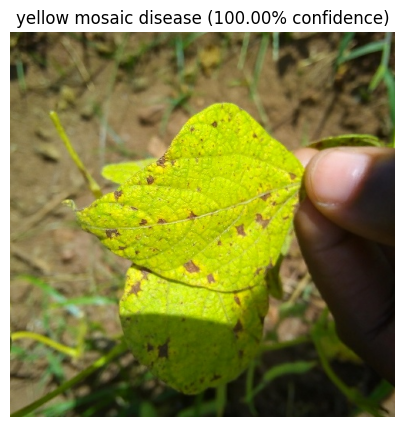

Predicted: yellow mosaic disease  |  Confidence: 100.00%


In [42]:
pred_class, conf = predict_and_show("/content/angular_leaf_spot_train.3.jpg",
                                    loaded_model, class_labels)
print(f"Predicted: {pred_class}  |  Confidence: {conf:.2f}%")